In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Network

## Template 03
### Flowers Dataset

<img src='../../../images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [2]:
###-----------------
### Import libraries
###-----------------

from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_squared_error,r2_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix, fn_plot_label# Custom utility

import tensorflow as tf

In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'flower_photos'
altName = 'cnn_base'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well

TEST_SIZE = 0.2

ALPHA = 0.001
EPOCHS = 201 # number of cycles to run
PATIENCE = 20
LR_PATIENCE = 15
FACTOR_LR = 0.1
BATCH_SIZE = 16 # inline of Training Rows being 60000
IMG_HEIGHT = 190
IMG_WIDTH = 190
LR_FACTOR  = 0.1
MIN_LR = 1e-5

# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,10),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Basic Hygiene

In [4]:
physical_devices = tf.config.list_physical_devices('GPU')

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [5]:
print (physical_devices)

[]


<h1>Creating dataset</h1>

In [6]:
start = -2.1
end = 2.1

delta = 0.001


#training data
X_train = np.arange(start,end+delta,delta)
y_true = 2 * np.square(X_train) + 2* np.sin(np.pi*X_train) ##2*X + 2*(sin(X*X))
y_rng = np.random.rand(X_train.shape[0]) - 0.5
y_train = y_true + y_rng


#testing data
X_test = np.arange(start,end+delta,delta*10)
y_true_test = 2 * np.square(X_test) + 2* np.sin(np.pi*X_test) ##2*X + 2*(sin(X*X))
y_rng = np.random.rand(X_test.shape[0]) - 0.5
y_test = y_true_test + y_rng * 2

y_test.min(),y_test.max()


(np.float64(-2.4796715408089343), np.float64(9.325824491056808))

In [7]:
X_train.shape[0]/16

262.5625

In [8]:
num_example = 262*BATCH_SIZE

X_train = X_train[:num_example]
y_train = y_train[:num_example]
y_true = y_true[:num_example]

X_train.shape, y_train.shape, y_true.shape


((4192,), (4192,), (4192,))

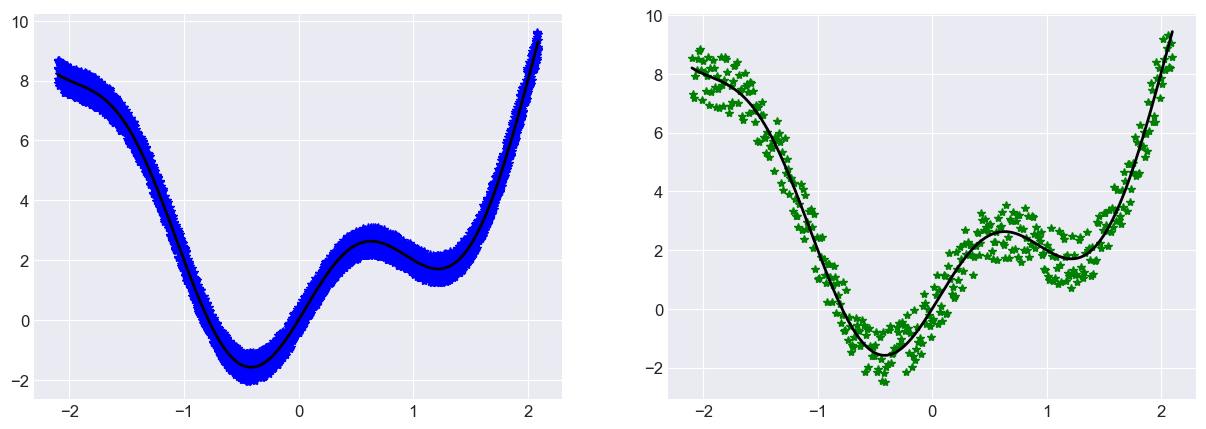

In [9]:
fig, axes = plt.subplots(1,2,figsize = (15,5))

ax = axes[0]
ax.plot(X_train, y_train, 'b*', label='Training Data')
ax.plot(X_train, y_true, 'k', label='True Data',linewidth = 2)

ax = axes[1]
ax.plot(X_test, y_test, 'g*', label='Testing Data')
ax.plot(X_test, y_true_test, 'k', label='True Data',linewidth = 2)


In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))


In [11]:
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [12]:
train_ds = train_ds.cache().prefetch(buffer_size=  tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=  tf.data.AUTOTUNE)


In [13]:
iter(train_ds).next()

(<tf.Tensor: shape=(16,), dtype=float64, numpy=
 array([-1.393,  0.162, -0.761,  1.342,  1.507, -1.675,  0.928,  0.755,
        -0.176, -1.284, -1.391, -0.142, -0.158, -1.66 , -0.407,  1.505])>,
 <tf.Tensor: shape=(16,), dtype=float64, numpy=
 array([ 6.09721033,  0.69522667, -0.19884279,  1.81330547,  2.2227347 ,
         7.25791141,  1.75014018,  2.64985572, -1.46632702,  4.78485306,
         5.96409005, -0.74271343, -0.75702998,  7.38323271, -1.10670729,
         2.9093939 ])>)

In [14]:
for fetures,labels in  train_ds.take(5):
    print(fetures.shape,labels.shape)

(16,) (16,)
(16,) (16,)
(16,) (16,)
(16,) (16,)
(16,) (16,)


# Define Model

In [15]:
#input features
num_features = 1



#funtional programming layer declaration
input_layer = tf.keras.Input(shape = (1,)) ## input layer
hidden_layer = tf.keras.layers.Dense(512,activation='relu')(input_layer) ##hidden layer 1
hidden_layer = tf.keras.layers.Dense(256,activation='relu')(hidden_layer) ##hidden layer 2
# hidden_layer3 = tf.keras.layers.Dense(128,activation='relu')(hidden_layer2)
output_layer = tf.keras.layers.Dense(1)(hidden_layer) ## output layer

model = tf.keras.Model(inputs = input_layer,outputs = output_layer)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,609 (518.00 KB)

 Trainable params: 132,609 (518.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
metrics =tf.keras.metrics.MeanAbsoluteError()#metrics

In [17]:
loss_fn = tf.keras.losses.MeanSquaredError() #loss function
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA) #optimizer

In [18]:
#call backs

tb_callback = tf.keras .callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss',
                                              patience=PATIENCE,
                                              verbose = 1,
                                              restore_best_weights=True,
)

chkpt_filepath =' modelDir/subDir/all_in.keras'
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    chkpt_filepath,
    monitor= 'val_loss',
    verbose = 1,
    save_best_only = True,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
   monitor='val_loss',
    factor= LR_FACTOR,
    patience = LR_PATIENCE,
    verbose = 1,
    mode = 'auto',
    min_lr=MIN_LR
)



In [19]:
model.compile(optimizer = optimizer,
             loss = loss_fn,
             metrics = [metrics])

In [20]:
history = model.fit(train_ds,
                    validation_data=test_ds,
                    callbacks = [es_callback,lr_callback],
                    epochs=EPOCHS)

Epoch 1/201
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.2621 - mean_absolute_error: 1.1094 - val_loss: 1.2450 - val_mean_absolute_error: 0.8765 - learning_rate: 0.0010
Epoch 2/201
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7267 - mean_absolute_error: 0.6467 - val_loss: 0.8182 - val_mean_absolute_error: 0.7345 - learning_rate: 0.0010
Epoch 3/201
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3533 - mean_absolute_error: 0.4673 - val_loss: 0.5084 - val_mean_absolute_error: 0.5933 - learning_rate: 0.0010
Epoch 4/201
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1645 - mean_absolute_error: 0.3296 - val_loss: 0.4207 - val_mean_absolute_error: 0.5499 - learning_rate: 0.0010
Epoch 5/201
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1247 - mean_absolute_error: 0.2918 - val_loss: 0.4128 - val_mean_absolute_error: 0.5438 - learning_rate: 0.0010
Epoch 6/201
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1158 - mean_absolute_error: 0.2824 - val_loss: 0.4019 - val_me

In [21]:
model.evaluate(train_ds,verbose=2)

262/262 - 0s - 1ms/step - loss: 0.0839 - mean_absolute_error: 0.2508


[0.0838853195309639, 0.250801682472229]

# Pedcidtions

In [22]:
y_pred_train = model(X_train).numpy()
y_pred_test = model(X_test).numpy()

train_df = pd.DataFrame(
    {'pred': y_pred_train[:,0],
     'y_train' : y_train,
     'y_true' : y_true}
)
train_df

test_df = pd.DataFrame(
    {'pred': y_pred_test[:,0],
     'y_test' : y_test,
     'y_true_test' : y_true_test}
)

In [23]:
y_true,y_pred = [],[]
for feat,lbls in train_ds:
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis = 1))
print(f'mean_sqaure_error : {mean_squared_error(y_true,y_pred)}')
print(f'r2_score : {r2_score(y_true,y_pred)}')

mean_sqaure_error : 17.410416469846577
r2_score : -0.9638572570253032


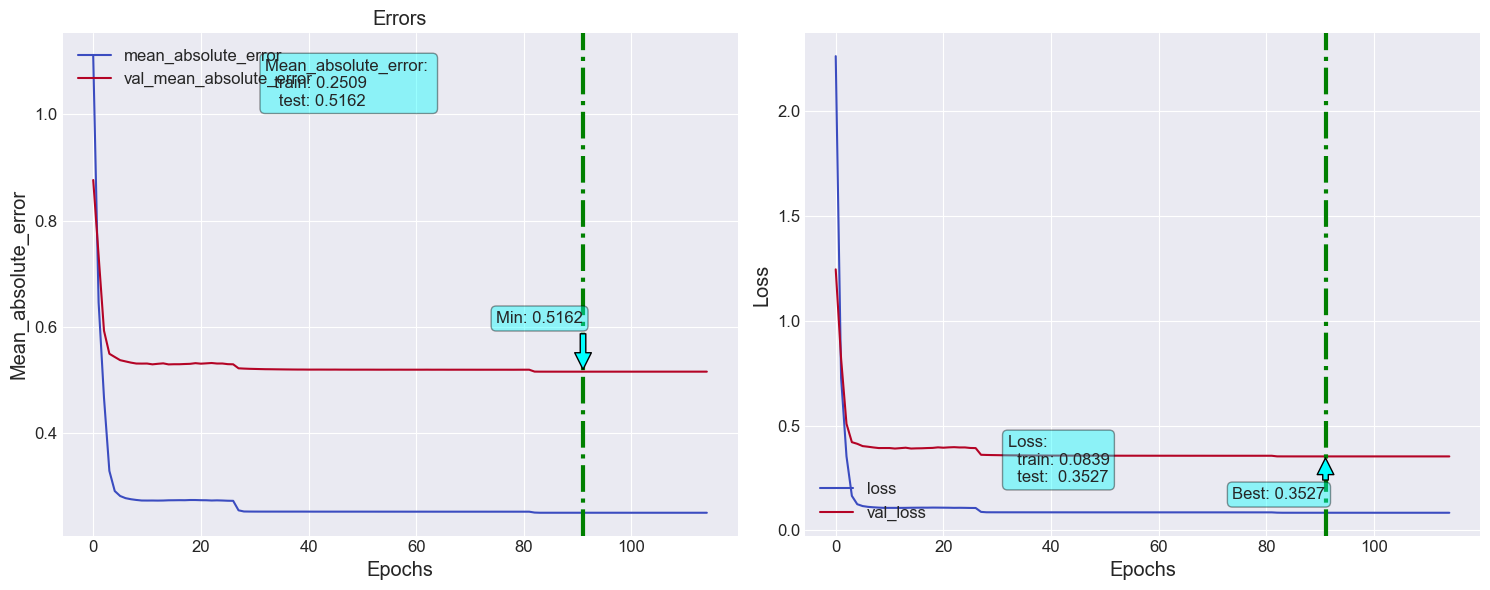

In [24]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [25]:
/ax = train_df.pred.plot(c = 'r',label = "pred")
train_df.y_true.plot(c = 'b',label = "true",ax = ax)

plt.scatter(x = train_df.index , y = train_df['y_train'] ,marker = '*')


SyntaxError: invalid syntax (3582085116.py, line 1)

In [ ]:
train_df

In [ ]:
# create training data
train_ds =tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, # path the the data directory
    validation_split=TEST_SIZE, # what ratio of validation data
    subset='training', # purpose
    seed=RANDOM_STATE,
    image_size=[IMG_HEIGHT, IMG_WIDTH], ## @@@ WHAT!
    batch_size=BATCH_SIZE
)
# test data
test_ds =tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, # path the the data directory
    validation_split=TEST_SIZE, # what ratio of validation data
    subset='validation', # purpose
    seed=RANDOM_STATE,
    image_size=[IMG_HEIGHT, IMG_WIDTH], ## @@@ WHAT!
    batch_size=BATCH_SIZE
)

In [ ]:
# is it picking class names
class_names = train_ds.class_names
class_names

In [ ]:
plt.figure(figsize=(15,8))

for images, labels in train_ds.take(1):
    for i in range (BATCH_SIZE):
        plt.subplot(int(BATCH_SIZE/8), 8, i +1)
        plt.grid(False)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15,8))

for images, labels in test_ds.take(1): # get me one batch

    for i in range (BATCH_SIZE): # loop over batch

        plt.subplot(int(BATCH_SIZE/8), 8, i +1) # access the axis

        plt.grid(False) # no to grid

        plt.imshow(images[i].numpy().astype('uint8')) # show image convert to numpy and int

        plt.title(class_names[labels[i]])

        plt.axis('off')

    plt.tight_layout()

plt.show()

In [ ]:
fn_plot_label(train_ds, test_ds)

In [ ]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
input_shape